# Phase 6 - Multi-Model OCR Comparison Pipeline

This notebook redesigns Phase 6 so that **all detection models use the same OCR pipeline**.

## What this notebook does
- loads multiple detector weights
- runs each model on the same image(s)
- selects the best detected plate for each model
- applies the **same crop + preprocessing + EasyOCR pipeline** to every model output
- builds a comparison table for reporting
- optionally saves results to CSV

## Why this design is better
This makes the comparison fair because only the **detector changes** between experiments. The OCR stage stays fixed.

**Pipeline used for every model:**

`image -> detector -> best plate box -> padded crop -> OCR preprocessing -> EasyOCR -> cleaned text`


In [1]:
# Run once if needed
# %pip install ultralytics easyocr opencv-python matplotlib pillow pandas torch torchvision

In [2]:
from pathlib import Path
import warnings
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision
from torchvision.transforms import functional as TF
from ultralytics import YOLO
import easyocr

warnings.filterwarnings(
    "ignore",
    message=".*pin_memory.*no accelerator is found.*",
)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

## 1) Configuration

This version is designed to be **hard to break**:

- it tries common model paths automatically
- it validates model files before loading them
- it keeps all result dictionaries in one fixed schema
- it shows safe tables even when some columns are missing
- it handles empty folders and missing single-image files cleanly

It compares:

- **YOLO**
- **Faster R-CNN**
- **RetinaNet**

All models go through the exact same pipeline:

**detection → best box → padded crop → preprocessing → EasyOCR → cleaned text**

In [3]:
PROJECT_ROOT = Path().resolve()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Main paths
TEST_FOLDER = PROJECT_ROOT / "test_images"
SINGLE_IMAGE_PATH = PROJECT_ROOT / "test_image.jpg"
OUTPUT_CSV = PROJECT_ROOT / "phase6_multimodel_ocr_results.csv"
GROUND_TRUTH_CSV = PROJECT_ROOT / "ground_truth_labels.csv"

DET_CONF = 0.25
PAD_RATIO = 0.08
OCR_LANGS = ["en"]
SHOW_SINGLE_IMAGE_RESULTS = True

def first_existing_path(*candidates):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    return Path(candidates[0])

YOLO_CANDIDATES = [
    PROJECT_ROOT / "runs" / "detect" / "plate_detector" / "weights" / "best.pt",
    PROJECT_ROOT / "runs" / "detect" / "runs" / "plate_detector" / "weights" / "best.pt",
    PROJECT_ROOT / "runs" / "plate_detector" / "weights" / "best.pt",
]

MODEL_SPECS = [
    {
        "name": "YOLOv8",
        "type": "yolo",
        "path": first_existing_path(*YOLO_CANDIDATES),
    },
    {
        "name": "FasterRCNN",
        "type": "torchvision",
        "arch": "fasterrcnn_resnet50_fpn",
        "num_classes": 2,
        "path": PROJECT_ROOT / "fasterrcnn_outputs" / "best_fasterrcnn_license_plate.pth",
    },
    {
        "name": "RetinaNet",
        "type": "torchvision",
        "arch": "retinanet_resnet50_fpn",
        "num_classes": 2,
        "path": PROJECT_ROOT / "retinanet_outputs" / "best_retinanet_license_plate.pth",
    },
]

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)
print("Test folder exists:", TEST_FOLDER.exists(), TEST_FOLDER)
print("Single image exists:", SINGLE_IMAGE_PATH.exists(), SINGLE_IMAGE_PATH)
print("Ground-truth CSV exists:", GROUND_TRUTH_CSV.exists(), GROUND_TRUTH_CSV)
print("\nConfigured models:")
for spec in MODEL_SPECS:
    print(f"- {spec['name']}: type={spec['type']}, exists={Path(spec['path']).exists()} -> {Path(spec['path'])}")

Project root: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project
Device: cpu
Test folder exists: True C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\test_images
Single image exists: True C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\test_image.jpg
Ground-truth CSV exists: False C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\ground_truth_labels.csv

Configured models:
- YOLOv8: type=yolo, exists=True -> C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\runs\detect\runs\plate_detector\weights\best.pt
- FasterRCNN: type=torchvision, exists=True -> C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\fasterrcnn_outputs\best_fasterrcnn_license_plate.pth
- RetinaNet: type=torchvision, exists=True -> C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\retinanet_outputs\best_retinanet_license_plate.pth


## 2) Optional YOLO auto-discovery

This cell finds **all** `best.pt` files under `runs/` so the notebook can recover even if the manual YOLO path changes.

In [4]:
def discover_yolo_best_weights(search_root: Path):
    if not search_root.exists():
        return []

    discovered = []
    seen = set()

    for best_path in sorted(search_root.rglob("best.pt")):
        best_path = best_path.resolve()
        if best_path in seen:
            continue
        seen.add(best_path)

        run_name = best_path.parent.parent.name
        discovered.append({
            "name": f"YOLO_{run_name}",
            "type": "yolo",
            "path": best_path,
        })
    return discovered

AUTO_DISCOVERED_YOLO_MODELS = discover_yolo_best_weights(PROJECT_ROOT / "runs")
AUTO_DISCOVERED_YOLO_MODELS

[{'name': 'YOLO_plate_detector',
  'type': 'yolo',
  'path': WindowsPath('C:/Users/jjrjg/OneDrive/Desktop/CMPS 261 Project/Plate-Detection-Project/runs/detect/runs/plate_detector/weights/best.pt')}]

In [5]:
# Keep the manual specs, but replace the manual YOLO entry if auto-discovery found a better one.
_valid_manual = [spec.copy() for spec in MODEL_SPECS if Path(spec["path"]).exists()]

manual_non_yolo = [spec for spec in _valid_manual if spec["type"] != "yolo"]
manual_yolo = [spec for spec in _valid_manual if spec["type"] == "yolo"]

if manual_yolo:
    chosen_yolo = manual_yolo
elif AUTO_DISCOVERED_YOLO_MODELS:
    chosen_yolo = [AUTO_DISCOVERED_YOLO_MODELS[0]]
else:
    chosen_yolo = []

VALID_MODEL_SPECS = chosen_yolo + manual_non_yolo

if not VALID_MODEL_SPECS:
    raise FileNotFoundError(
        "No valid model weights were found. Check your model paths in MODEL_SPECS."
    )

print("Models that will actually be loaded:")
for spec in VALID_MODEL_SPECS:
    print(f"- {spec['name']}: type={spec['type']} -> {Path(spec['path'])}")

Models that will actually be loaded:
- YOLOv8: type=yolo -> C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\runs\detect\runs\plate_detector\weights\best.pt
- FasterRCNN: type=torchvision -> C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\fasterrcnn_outputs\best_fasterrcnn_license_plate.pth
- RetinaNet: type=torchvision -> C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\retinanet_outputs\best_retinanet_license_plate.pth


## 3) Load models and OCR reader

In [6]:
def build_torchvision_detector(arch: str, num_classes: int):
    if arch == "fasterrcnn_resnet50_fpn":
        model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
            weights=None,
            weights_backbone=None,
        )
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
            in_features, num_classes
        )
        return model

    if arch == "retinanet_resnet50_fpn":
        return torchvision.models.detection.retinanet_resnet50_fpn(
            weights=None,
            weights_backbone=None,
            num_classes=num_classes,
        )

    if arch == "retinanet_resnet50_fpn_v2":
        return torchvision.models.detection.retinanet_resnet50_fpn_v2(
            weights=None,
            weights_backbone=None,
            num_classes=num_classes,
        )

    raise ValueError(f"Unsupported torchvision architecture: {arch}")


def extract_state_dict(checkpoint):
    if isinstance(checkpoint, torch.nn.Module):
        return None

    if not isinstance(checkpoint, dict):
        return checkpoint

    for key in ["model_state_dict", "state_dict", "model"]:
        if key in checkpoint and isinstance(checkpoint[key], dict):
            return checkpoint[key]

    return checkpoint


def load_torchvision_model_with_fallback(spec, device=DEVICE):
    model_path = Path(spec["path"])
    arch_candidates = []
    if "arch" in spec:
        arch_candidates.append(spec["arch"])

    # Helpful fallback for RetinaNet in case v1/v2 mismatch.
    if spec.get("arch") == "retinanet_resnet50_fpn":
        arch_candidates.append("retinanet_resnet50_fpn_v2")
    elif spec.get("arch") == "retinanet_resnet50_fpn_v2":
        arch_candidates.append("retinanet_resnet50_fpn")

    # Deduplicate while preserving order.
    seen = set()
    arch_candidates = [a for a in arch_candidates if not (a in seen or seen.add(a))]

    checkpoint = torch.load(model_path, map_location=device)

    if isinstance(checkpoint, torch.nn.Module):
        model = checkpoint.to(device)
        model.eval()
        return model, spec.get("arch", "loaded_module"), [], []

    state_dict = extract_state_dict(checkpoint)
    last_error = None

    for arch in arch_candidates:
        try:
            model = build_torchvision_detector(arch=arch, num_classes=int(spec.get("num_classes", 2))).to(device)
            missing, unexpected = model.load_state_dict(state_dict, strict=False)
            model.eval()
            return model, arch, missing, unexpected
        except Exception as e:
            last_error = e

    raise RuntimeError(
        f"Could not load {spec['name']} from {model_path}. "
        f"Tried architectures: {arch_candidates}. Last error: {last_error}"
    )


def load_model_from_spec(spec, device=DEVICE):
    model_type = spec["type"]
    model_path = Path(spec["path"])

    if model_type == "yolo":
        model = YOLO(str(model_path))
        return {
            "name": spec["name"],
            "type": model_type,
            "model": model,
            "path": model_path,
            "load_notes": "",
        }

    if model_type == "torchvision":
        model, loaded_arch, missing, unexpected = load_torchvision_model_with_fallback(spec, device=device)
        print(
            f"[{spec['name']}] loaded arch={loaded_arch} | missing keys={len(missing)} | unexpected keys={len(unexpected)}"
        )
        return {
            "name": spec["name"],
            "type": model_type,
            "arch": loaded_arch,
            "model": model,
            "path": model_path,
            "load_notes": f"missing={len(missing)}, unexpected={len(unexpected)}",
        }

    raise ValueError(f"Unsupported model type: {model_type}")


loaded_models = []
for spec in VALID_MODEL_SPECS:
    loaded_models.append(load_model_from_spec(spec, device=DEVICE))

models = {bundle["name"]: bundle for bundle in loaded_models}
reader = easyocr.Reader(OCR_LANGS, gpu=(DEVICE == "cuda"))

print(f"\nLoaded {len(models)} model(s): {list(models.keys())}")
print("EasyOCR ready")

[FasterRCNN] loaded arch=fasterrcnn_resnet50_fpn | missing keys=0 | unexpected keys=0


Using CPU. Note: This module is much faster with a GPU.


[RetinaNet] loaded arch=retinanet_resnet50_fpn | missing keys=0 | unexpected keys=0

Loaded 3 model(s): ['YOLOv8', 'FasterRCNN', 'RetinaNet']
EasyOCR ready


## 4) Shared helper functions

These functions enforce a **single fixed output schema** so the tables do not break.

In [7]:
RESULT_COLUMNS = [
    "image_name",
    "model_name",
    "model_type",
    "detected",
    "detector_confidence",
    "raw_text",
    "cleaned_text",
    "ocr_confidence",
    "box",
    "ocr_raw_results",
    "detector_raw_output_type",
]

def clean_plate_text(text: str) -> str:
    text = "" if text is None else str(text)
    text = text.upper()
    text = re.sub(r"[^A-Z0-9]", "", text)
    return text


def expand_box(x1, y1, x2, y2, img_w, img_h, pad_ratio=0.08):
    box_w = max(0, x2 - x1)
    box_h = max(0, y2 - y1)
    pad_x = int(box_w * pad_ratio)
    pad_y = int(box_h * pad_ratio)

    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(img_w, x2 + pad_x)
    y2 = min(img_h, y2 + pad_y)
    return int(x1), int(y1), int(x2), int(y2)


def preprocess_plate_for_ocr(crop_bgr):
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresh


def get_best_box_from_arrays(boxes, scores, conf=0.25):
    if boxes is None or scores is None:
        return None, None
    if len(boxes) == 0 or len(scores) == 0:
        return None, None

    boxes = np.asarray(boxes)
    scores = np.asarray(scores).reshape(-1)

    usable = np.isfinite(scores)
    if usable.sum() == 0:
        return None, None

    boxes = boxes[usable]
    scores = scores[usable]

    valid = scores >= conf
    if valid.sum() == 0:
        return None, None

    boxes = boxes[valid]
    scores = scores[valid]

    best_idx = int(np.argmax(scores))
    x1, y1, x2, y2 = boxes[best_idx][:4].astype(int).tolist()
    return (x1, y1, x2, y2), float(scores[best_idx])


def detect_best_plate_yolo(image_bgr, model_bundle, conf=0.25):
    model = model_bundle["model"]
    results = model.predict(source=image_bgr, conf=conf, verbose=False)[0]

    if results.boxes is None or len(results.boxes) == 0:
        return None, None, results

    boxes = results.boxes.xyxy.cpu().numpy()
    scores = results.boxes.conf.cpu().numpy()
    best_box, best_score = get_best_box_from_arrays(boxes, scores, conf=conf)
    return best_box, best_score, results


def detect_best_plate_torchvision(image_bgr, model_bundle, conf=0.25):
    model = model_bundle["model"]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_tensor = TF.to_tensor(image_rgb).to(DEVICE)

    with torch.no_grad():
        outputs = model([image_tensor])[0]

    boxes = outputs.get("boxes", torch.empty((0, 4))).detach().cpu().numpy()
    scores = outputs.get("scores", torch.empty((0,))).detach().cpu().numpy()
    best_box, best_score = get_best_box_from_arrays(boxes, scores, conf=conf)
    return best_box, best_score, outputs


def detect_best_plate(image_bgr, model_bundle, conf=0.25):
    if model_bundle["type"] == "yolo":
        return detect_best_plate_yolo(image_bgr, model_bundle, conf=conf)
    if model_bundle["type"] == "torchvision":
        return detect_best_plate_torchvision(image_bgr, model_bundle, conf=conf)
    raise ValueError(f"Unsupported model bundle type: {model_bundle['type']}")


def crop_plate(image_bgr, box, pad_ratio=0.08):
    h, w = image_bgr.shape[:2]
    x1, y1, x2, y2 = box
    x1, y1, x2, y2 = expand_box(x1, y1, x2, y2, w, h, pad_ratio=pad_ratio)

    if x2 <= x1 or y2 <= y1:
        return None, (x1, y1, x2, y2)

    crop = image_bgr[y1:y2, x1:x2]
    if crop is None or crop.size == 0:
        return None, (x1, y1, x2, y2)

    return crop, (x1, y1, x2, y2)


def run_ocr(processed_image, reader):
    results = reader.readtext(processed_image)
    if not results:
        return "", 0.0, "", []

    texts, confs = [], []
    for bbox, text, conf in results:
        texts.append(str(text))
        try:
            confs.append(float(conf))
        except Exception:
            pass

    raw_text = " ".join(texts).strip()
    avg_conf = float(sum(confs) / len(confs)) if confs else 0.0
    cleaned_text = clean_plate_text(raw_text)
    return raw_text, avg_conf, cleaned_text, results


def draw_detection(image_bgr, box, score, label_text="Plate"):
    output = image_bgr.copy()
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 2)
    score_text = "NA" if score is None else f"{float(score):.2f}"
    cv2.putText(
        output,
        f"{label_text} | {score_text}",
        (x1, max(25, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )
    return output


def make_empty_result(image_name, model_bundle, detector_raw_output_type="None"):
    return {
        "image_name": image_name,
        "model_name": model_bundle["name"],
        "model_type": model_bundle["type"],
        "detected": False,
        "detector_confidence": 0.0,
        "raw_text": "",
        "cleaned_text": "",
        "ocr_confidence": 0.0,
        "box": None,
        "ocr_raw_results": [],
        "detector_raw_output_type": detector_raw_output_type,
    }


def ensure_result_schema(df):
    df = df.copy()
    for col in RESULT_COLUMNS:
        if col not in df.columns:
            if col in ["detected"]:
                df[col] = False
            elif col in ["detector_confidence", "ocr_confidence"]:
                df[col] = 0.0
            else:
                df[col] = None
    return df[RESULT_COLUMNS]


def safe_display_results(df):
    df = ensure_result_schema(df)
    display_cols = [
        "image_name",
        "model_name",
        "model_type",
        "detected",
        "detector_confidence",
        "cleaned_text",
        "ocr_confidence",
    ]
    sort_cols = [c for c in ["image_name", "model_name"] if c in df.columns]
    out = df[display_cols]
    if sort_cols:
        out = out.sort_values(sort_cols)
    display(out.reset_index(drop=True))

## 5) Single shared pipeline for one model on one image

In [8]:
def detect_and_read_plate(image_path, model_bundle, reader, det_conf=0.25, pad_ratio=0.08, show=False):
    image_path = Path(image_path)
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    result = make_empty_result(image_path.name, model_bundle)

    try:
        best_box, best_score, raw_detector_output = detect_best_plate(image_bgr, model_bundle, conf=det_conf)
        result["detector_raw_output_type"] = str(type(raw_detector_output))
    except Exception as e:
        result["detector_raw_output_type"] = f"ERROR: {type(e).__name__}: {e}"
        return result

    if best_box is None:
        return result

    plate_crop_bgr, padded_box = crop_plate(image_bgr, best_box, pad_ratio=pad_ratio)
    result["detected"] = True
    result["detector_confidence"] = float(best_score) if best_score is not None else 0.0
    result["box"] = padded_box

    if plate_crop_bgr is None or plate_crop_bgr.size == 0:
        return result

    try:
        processed_plate = preprocess_plate_for_ocr(plate_crop_bgr)
        raw_text, ocr_conf, cleaned_text, ocr_results = run_ocr(processed_plate, reader)
    except Exception as e:
        result["raw_text"] = f"OCR_ERROR:{type(e).__name__}"
        result["cleaned_text"] = ""
        result["ocr_confidence"] = 0.0
        result["ocr_raw_results"] = [str(e)]
        return result

    result["raw_text"] = raw_text
    result["cleaned_text"] = cleaned_text
    result["ocr_confidence"] = float(ocr_conf)
    result["ocr_raw_results"] = ocr_results

    if show:
        detected_img = draw_detection(image_bgr, best_box, best_score, label_text=model_bundle["name"])
        detected_img_rgb = cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB)
        plate_crop_rgb = cv2.cvtColor(plate_crop_bgr, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(18, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(detected_img_rgb)
        plt.title(f"{model_bundle['name']}: detected plate\nDetector confidence: {result['detector_confidence']:.2f}")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(plate_crop_rgb)
        plt.title("Plate crop")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(processed_plate, cmap="gray")
        plt.title(f"Preprocessed for OCR\nOCR text: {cleaned_text if cleaned_text else '[empty]'}")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    return result

## 6) Run all models on one image

Use this to visually inspect how each model behaves before running the full batch.

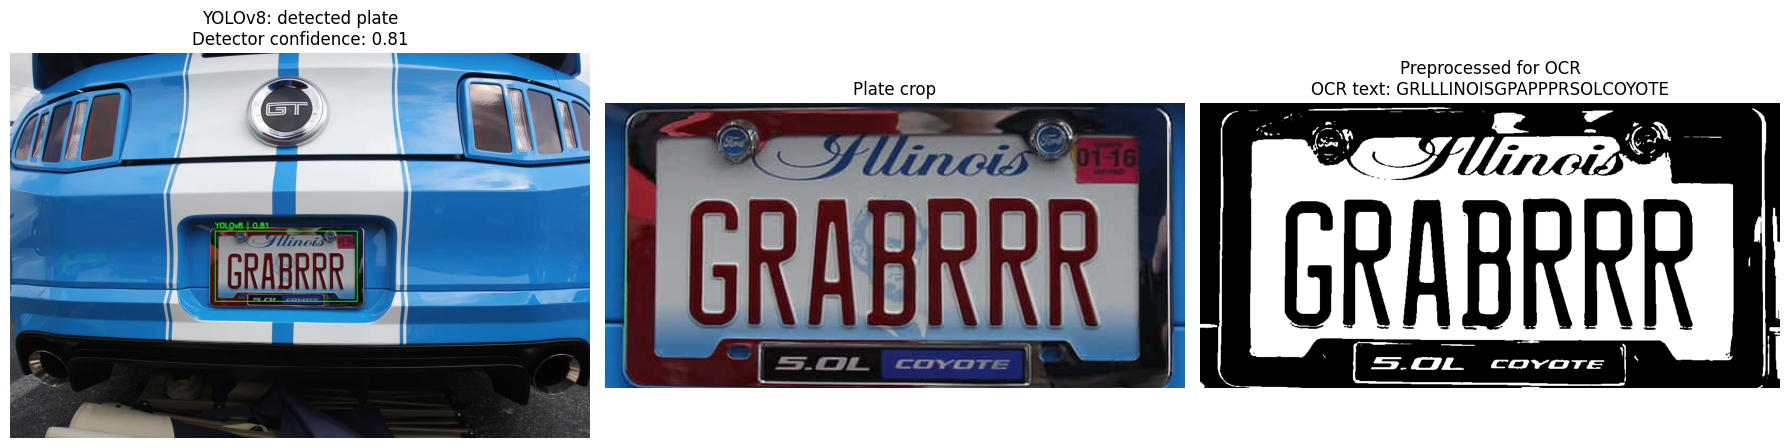

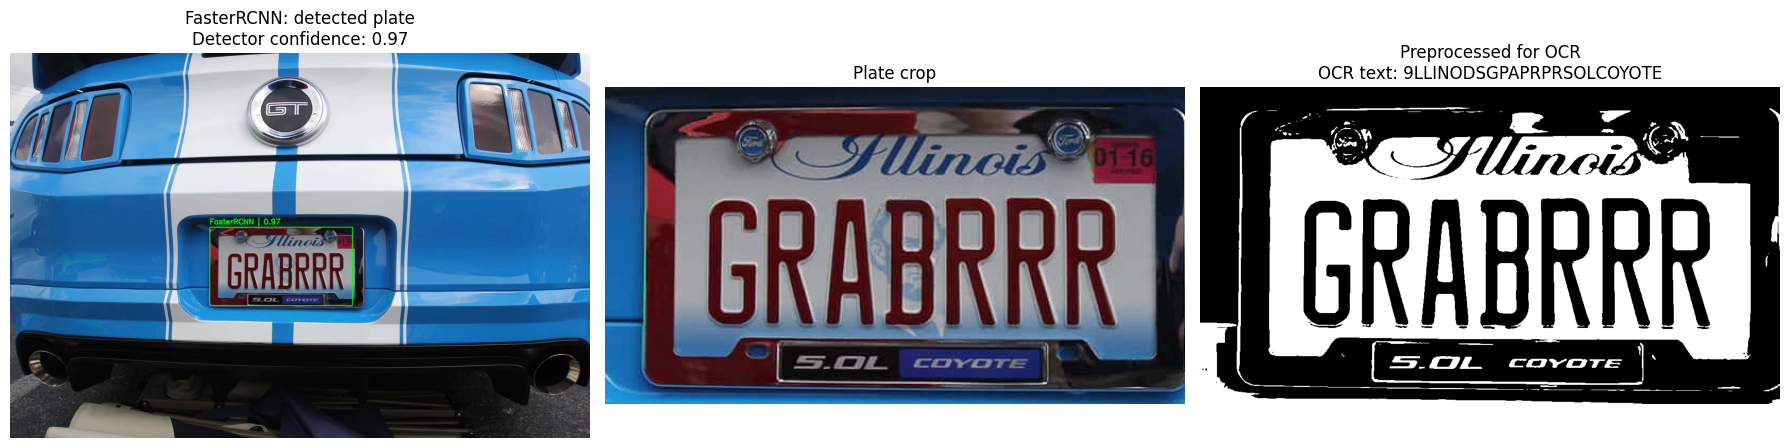

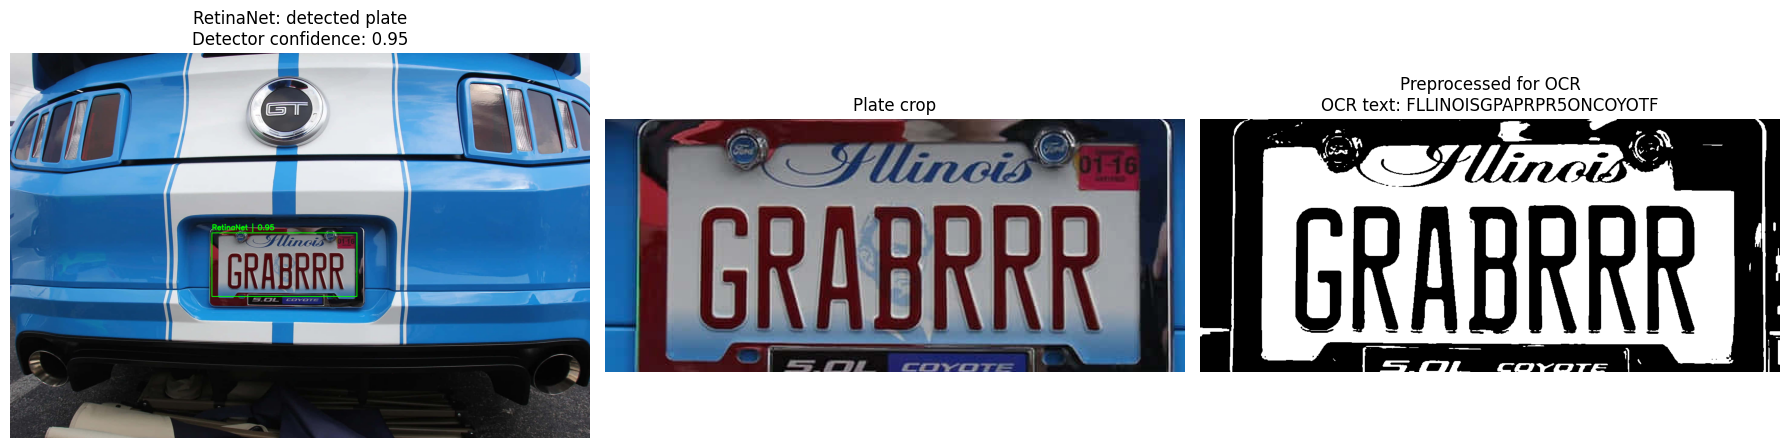

,image_name,model_name,model_type,detected,detector_confidence,cleaned_text,ocr_confidence
0,test_image.jpg,FasterRCNN,torchvision,True,0.972718,9LLINODSGPAPRPRSOLCOYOTE,0.488857
1,test_image.jpg,RetinaNet,torchvision,True,0.954871,FLLINOISGPAPRPR5ONCOYOTF,0.287602
2,test_image.jpg,YOLOv8,yolo,True,0.808353,GRLLLINOISGPAPPPRSOLCOYOTE,0.470999


In [9]:
single_image_results = []

if SINGLE_IMAGE_PATH.exists():
    for model_name, model_bundle in models.items():
        result = detect_and_read_plate(
            image_path=SINGLE_IMAGE_PATH,
            model_bundle=model_bundle,
            reader=reader,
            det_conf=DET_CONF,
            pad_ratio=PAD_RATIO,
            show=SHOW_SINGLE_IMAGE_RESULTS,
        )
        single_image_results.append(result)

    single_image_df = ensure_result_schema(pd.DataFrame(single_image_results))
    safe_display_results(single_image_df)
else:
    print(f"Single image not found: {SINGLE_IMAGE_PATH}")

## 7) Batch evaluation across all images and all models

This is the main experiment cell for your report.

In [10]:
def list_image_files(folder: Path):
    image_files = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"):
        image_files.extend(folder.glob(ext))
    return sorted(image_files)

if not TEST_FOLDER.exists():
    raise FileNotFoundError(f"Test folder not found: {TEST_FOLDER}")

image_files = list_image_files(TEST_FOLDER)
print(f"Found {len(image_files)} image(s) in {TEST_FOLDER}")

if len(image_files) == 0:
    print("No images found. Add images to TEST_FOLDER, then rerun this cell.")
    results_df = ensure_result_schema(pd.DataFrame(columns=RESULT_COLUMNS))
else:
    all_results = []

    for img_path in image_files:
        for model_name, model_bundle in models.items():
            result = detect_and_read_plate(
                image_path=img_path,
                model_bundle=model_bundle,
                reader=reader,
                det_conf=DET_CONF,
                pad_ratio=PAD_RATIO,
                show=False,
            )
            all_results.append(result)

    results_df = ensure_result_schema(pd.DataFrame(all_results))

print("results_df shape:", results_df.shape)
print("results_df columns:", results_df.columns.tolist())
results_df.head()

Found 24 image(s) in C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\test_images
results_df shape: (72, 11)
results_df columns: ['image_name', 'model_name', 'model_type', 'detected', 'detector_confidence', 'raw_text', 'cleaned_text', 'ocr_confidence', 'box', 'ocr_raw_results', 'detector_raw_output_type']


,image_name,model_name,model_type,detected,detector_confidence,raw_text,cleaned_text,ocr_confidence,box,ocr_raw_results,detector_raw_output_type
0,Cars10.png,YOLOv8,yolo,True,0.626442,TN37 C5 2765,TN37C52765,0.734153,"(121, 0, 324, 168)","[([[np.float64(71.64370978203266), np.float64(95.65748391281306)], [np.float64(352.11370751721444), np.float64(37.105420391737056)], [np.float64(366.35629021796734), np.float64(106.34251608718694)...",<class 'ultralytics.engine.results.Results'>
1,Cars10.png,FasterRCNN,torchvision,True,0.678057,TN37Cs 2765,TN37CS2765,0.648414,"(149, 3, 315, 160)","[([[np.float64(16.33738971823079), np.float64(90.70121691546923)], [np.float64(295.2287294479449), np.float64(31.57283344898231)], [np.float64(308.6626102817692), np.float64(98.29878308453077)], [...",<class 'dict'>
2,Cars10.png,RetinaNet,torchvision,True,0.369040,cs N37,CSN37,0.498194,"(187, 18, 307, 70)","[([[np.int32(148), np.int32(8)], [np.int32(224), np.int32(8)], [np.int32(224), np.int32(94)], [np.int32(148), np.int32(94)]], cs, 0.23722597876043802), ([[np.float64(-10.141150910288758), np.float...",<class 'dict'>
3,Cars11.png,YOLOv8,yolo,True,0.853874,LR S116K,LRS116K,0.502614,"(110, 199, 291, 237)","[([[np.int32(34), np.int32(3)], [np.int32(326), np.int32(3)], [np.int32(326), 76], [np.int32(34), 76]], LR S116K, 0.5026137601973604)]",<class 'ultralytics.engine.results.Results'>
4,Cars11.png,FasterRCNN,torchvision,True,0.951264,LR 5i6k,LR5I6K,0.291560,"(97, 192, 294, 246)","[([[np.int32(60), np.int32(18)], [np.int32(352), np.int32(18)], [np.int32(352), np.int32(90)], [np.int32(60), np.int32(90)]], LR 5i6k, 0.2915598370896434)]",<class 'dict'>


## 8) Comparison tables

These summaries are useful directly in your report.

In [11]:
safe_display_results(results_df)

,image_name,model_name,model_type,detected,detector_confidence,cleaned_text,ocr_confidence
0,Cars10.png,FasterRCNN,torchvision,True,0.678057,TN37CS2765,0.648414
1,Cars10.png,RetinaNet,torchvision,True,0.369040,CSN37,0.498194
2,Cars10.png,YOLOv8,yolo,True,0.626442,TN37C52765,0.734153
3,Cars11.png,FasterRCNN,torchvision,True,0.951264,LR5I6K,0.291560
4,Cars11.png,RetinaNet,torchvision,True,0.627300,R5I6K,0.106557
...,...,...,...,...,...,...,...
67,Cars8.png,RetinaNet,torchvision,True,0.973933,6526JHD,0.801328
68,Cars8.png,YOLOv8,yolo,True,0.834034,6526JHD,0.823205
69,Cars9.png,FasterRCNN,torchvision,True,0.967845,HHO1AY8866,0.227100
70,Cars9.png,RetinaNet,torchvision,True,0.826753,MHO1AV8866,0.638883


In [12]:
summary_df = (
    ensure_result_schema(results_df)
    .groupby(["model_name", "model_type"], as_index=False)
    .agg(
        total_images=("image_name", "count"),
        detections=("detected", "sum"),
        mean_detector_confidence=("detector_confidence", "mean"),
        mean_ocr_confidence=("ocr_confidence", "mean"),
        nonempty_ocr_outputs=("cleaned_text", lambda s: int((s.fillna("").str.len() > 0).sum())),
    )
)

summary_df["detection_rate"] = np.where(
    summary_df["total_images"] > 0,
    summary_df["detections"] / summary_df["total_images"],
    0.0,
)
summary_df["ocr_output_rate"] = np.where(
    summary_df["total_images"] > 0,
    summary_df["nonempty_ocr_outputs"] / summary_df["total_images"],
    0.0,
)

summary_df.sort_values(["model_type", "model_name"]).reset_index(drop=True)

,model_name,model_type,total_images,detections,mean_detector_confidence,mean_ocr_confidence,nonempty_ocr_outputs,detection_rate,ocr_output_rate
0,FasterRCNN,torchvision,24,23,0.842583,0.283339,17,0.958333,0.708333
1,RetinaNet,torchvision,24,24,0.808563,0.280101,17,1.000000,0.708333
2,YOLOv8,yolo,24,23,0.750534,0.342075,17,0.958333,0.708333


## 9) Optional exact-match evaluation

If `ground_truth_labels.csv` does not exist, the next cell will automatically create a template with these columns:

- `image_name`
- `ground_truth`

Then you can fill in the real plate text manually and rerun the cell.


In [16]:
def levenshtein_distance(a: str, b: str) -> int:
    a = "" if a is None else str(a)
    b = "" if b is None else str(b)

    if a == b:
        return 0
    if len(a) == 0:
        return len(b)
    if len(b) == 0:
        return len(a)

    dp = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        prev = dp[0]
        dp[0] = i
        for j, cb in enumerate(b, start=1):
            temp = dp[j]
            if ca == cb:
                dp[j] = prev
            else:
                dp[j] = 1 + min(prev, dp[j], dp[j - 1])
            prev = temp
    return dp[-1]

if not GROUND_TRUTH_CSV.exists():
    template_df = (
        ensure_result_schema(results_df)[["image_name"]]
        .dropna()
        .drop_duplicates()
        .sort_values("image_name")
        .reset_index(drop=True)
    )
    template_df["ground_truth"] = ""
    template_df.to_csv(GROUND_TRUTH_CSV, index=False)

    print(f"Created template ground-truth CSV: {GROUND_TRUTH_CSV}")
    print("Fill in the 'ground_truth' column with the correct license plate text, then rerun this cell.")
    display(template_df.head(10))
else:
    gt_df = pd.read_csv(GROUND_TRUTH_CSV)

    required_gt_cols = {"image_name", "ground_truth"}
    missing_gt_cols = required_gt_cols - set(gt_df.columns)
    if missing_gt_cols:
        raise ValueError(f"ground_truth_labels.csv is missing required columns: {sorted(missing_gt_cols)}")

    gt_df = gt_df.copy()
    gt_df["image_name"] = gt_df["image_name"].astype(str)
    gt_df["ground_truth"] = gt_df["ground_truth"].fillna("").astype(str).map(clean_plate_text)

    eval_df = ensure_result_schema(results_df).merge(gt_df, on="image_name", how="left")
    eval_df["exact_match"] = eval_df["cleaned_text"].fillna("") == eval_df["ground_truth"].fillna("")
    eval_df["edit_distance"] = [
        levenshtein_distance(pred, gt) if pd.notna(gt) else np.nan
        for pred, gt in zip(eval_df["cleaned_text"], eval_df["ground_truth"])
    ]
    eval_df["cer"] = [
        (dist / max(len(gt), 1)) if pd.notna(gt) else np.nan
        for dist, gt in zip(eval_df["edit_distance"], eval_df["ground_truth"])
    ]

    exact_match_summary = (
        eval_df.groupby(["model_name", "model_type"], as_index=False)
        .agg(
            total_images=("image_name", "count"),
            exact_matches=("exact_match", "sum"),
            mean_edit_distance=("edit_distance", "mean"),
            mean_cer=("cer", "mean"),
        )
    )
    exact_match_summary["exact_match_rate"] = np.where(
        exact_match_summary["total_images"] > 0,
        exact_match_summary["exact_matches"] / exact_match_summary["total_images"],
        0.0,
    )
    display(exact_match_summary.sort_values(["model_type", "model_name"]).reset_index(drop=True))



,model_name,model_type,total_images,exact_matches,mean_edit_distance,mean_cer,exact_match_rate
0,FasterRCNN,torchvision,24,7,4.583333,4.583333,0.291667
1,RetinaNet,torchvision,24,7,4.875000,4.875000,0.291667
2,YOLOv8,yolo,24,7,5.375000,5.375000,0.291667


## 10) Save results

This saves the full per-image, per-model comparison table.

In [14]:
results_df = ensure_result_schema(results_df)
results_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved results to: {OUTPUT_CSV}")

Saved results to: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\phase6_multimodel_ocr_results.csv


## Suggested reporting angle

This notebook now supports an **end-to-end comparison**:

1. each detector predicts a plate region
2. the same crop padding is applied
3. the same preprocessing is applied
4. the same OCR engine reads the plate
5. the outputs are compared with the same metrics

That lets you report both:

- **detection quality** (detection rate, detector confidence)
- **recognition quality** (OCR output rate, exact match rate, CER)

This is stronger than reporting detector metrics alone, because a detector can have a decent box while still producing worse OCR due to imperfect localization.